# 📊 E-Commerce Sales Analytics using Pandas & Matplotlib

In this notebook, we perform **Exploratory Data Analysis (EDA)** and **Data Visualization** on an E-Commerce Sales dataset using:

- **Pandas** → Data handling and analysis
- **Matplotlib** → Data visualization

The notebook covers:

- Monthly revenue analysis
- Scatter plots
- Bar charts
- Histograms
- Stacked visualizations
- Grouped analysis
- Confidence bands
- Revenue comparisons

## 📚 Import Libraries and 📂 Load Dataset
This section imports the required libraries and loads the dataset using `pd.read_csv()`.
- `parse_dates=["order_date"]`
  - Converts the `order_date` column into datetime format.
  - Helps in time-series analysis and resampling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "ecommerce_sales_analytics_5000.csv",
    parse_dates=["order_date"]
)

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [3]:
df.shape

(5000, 12)

## 📈 Monthly Revenue Trend (Line Plot)

This section calculates total monthly revenue and visualizes revenue trends over time by using line plot.

### Concepts Used

- Time Series Analysis: `set_index()`: Sets `order_date` as index.
- Resampling: `resample("ME")`: Resamples data monthly.
- `sum()`: Calculates total revenue per month.

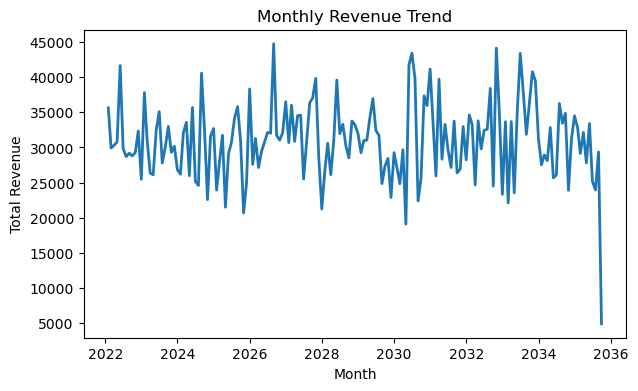

In [4]:
monthly_revenue = (
    df.set_index("order_date")["revenue"]
    .resample("ME")
    .sum()
)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    linewidth=2
)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
fig.savefig("Monthly Revenue Trend.png", dpi=100)
plt.show()

## 🔍 Unit Price vs Revenue (Scatter Plot)

This section visualizes the relationship between Product Unit Price and Revenue by using scatter plot:

### Scatter plots help identify:
- Correlation
- Outliers
- Distribution patterns

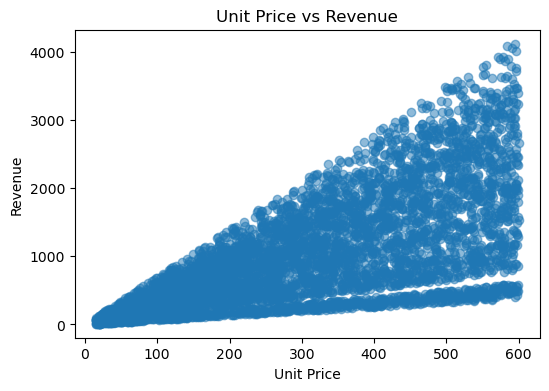

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(
    df["unit_price"],
    df["revenue"],
    alpha=0.5
)
ax.set_title("Unit Price vs Revenue")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Revenue")
fig.savefig("Unit Price vs Revenue.png", dpi=100)
plt.show()

## 💳 Payment Method Analysis (Bar Chart)
This section analyzes the number of orders by payment method.
- `value_counts()`: Counts occurrences of each payment method.

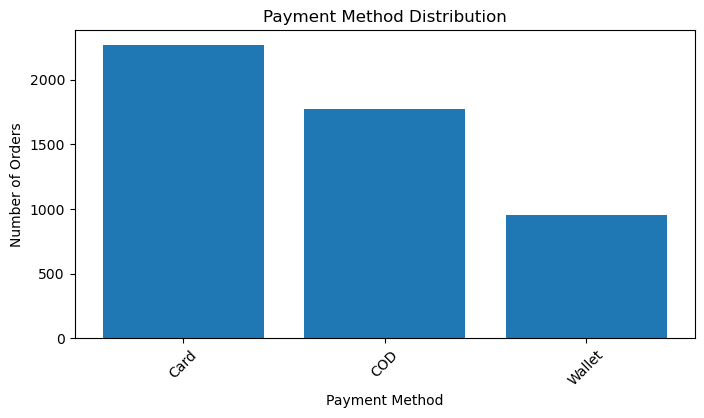

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(
    df["payment_method"].value_counts().index,
    df["payment_method"].value_counts().values
)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Number of Orders")
ax.set_title("Payment Method Distribution")
ax.tick_params(
    axis="x",
    rotation=45
)
fig.savefig("Payment Method Distribution.png", dpi=100)
plt.show()

## 📊 Revenue Analysis by Product Category (Bar Chart)

### Total Revenue by Category
calculates total revenue generated by each product category by using bar chart.
- GroupBy Aggregation: groupby() and sum()

### Average Revenue by Category with Variability
calculates Mean Revenue and Standard Deviation for each product category.
- Aggregation: `agg(["mean","std"])`
- Error Bars

In [7]:
# Total Revenue by Category
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
)

# Mean & Standard Deviation
stats = (
    df.groupby("product_category")["revenue"]
    .agg(["mean", "std"])
)

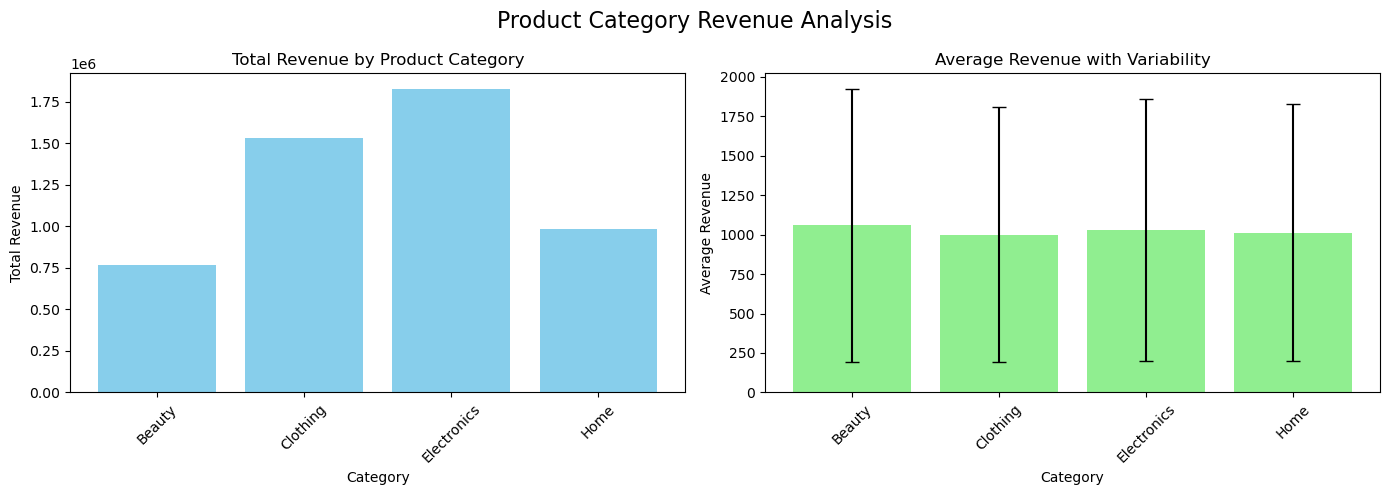

In [8]:
# Create Subplots
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Plot 1 → Total Revenue
axes[0].bar(
    category_revenue.index,
    category_revenue.values,
    color="skyblue"
)
axes[0].set_title(
    "Total Revenue by Product Category"
)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Revenue")
axes[0].tick_params(
    axis="x",
    rotation=45
)

# Plot 2 → Average Revenue
axes[1].bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5,
    color="lightgreen"
)
axes[1].set_title(
    "Average Revenue with Variability"
)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Average Revenue")
axes[1].tick_params(
    axis="x",
    rotation=45
)

# Main Figure Title
fig.suptitle(
    "Product Category Revenue Analysis",
    fontsize=16
)
fig.savefig("Product Category Revenue Analysis.png", dpi=100)

plt.tight_layout()
plt.show()

## 🌍 Revenue by Category and Region (Bar Chart)
This section analyzes revenue across Product Categories and Regions

### UnStacked Bars
- Multi-Level Grouping
- Unstacking
- Grouped Bar Chart

### Stacked Bars
They help compare:
- Total revenue
- Individual region contribution

In [9]:
grouped = (
    df.groupby(["product_category", "region"])["revenue"]
    .sum()
    .unstack()
)

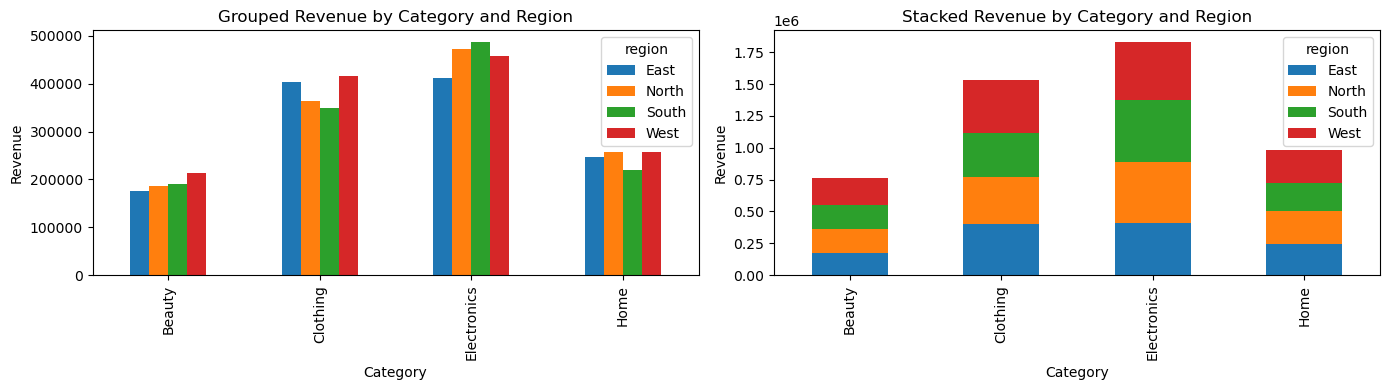

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

# Grouped Bar Chart
grouped.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Grouped Revenue by Category and Region")
axes[0].set_ylabel("Revenue")
axes[0].set_xlabel("Category")

# Stacked Bar Chart
grouped.plot(
    kind="bar",
    stacked=True,
    ax=axes[1]
)

axes[1].set_title("Stacked Revenue by Category and Region")
axes[1].set_ylabel("Revenue")
axes[1].set_xlabel("Category")

fig.savefig("Revenue by Category and Region.png", dpi=100)

plt.tight_layout()
plt.show()

## 📊 Delivery Time & Customer Rating Analysis (Histogram)
### 1️⃣ Delivery Days Distribution
Shows how delivery times are distributed across customer orders.
This helps identify:
- Common delivery durations
- Delayed deliveries
- Delivery consistency
### 2️⃣ Customer Rating Distribution
Displays the frequency of customer ratings given to orders.
This helps analyze:
- Overall customer satisfaction
- Most common rating values
- Rating trends and variability

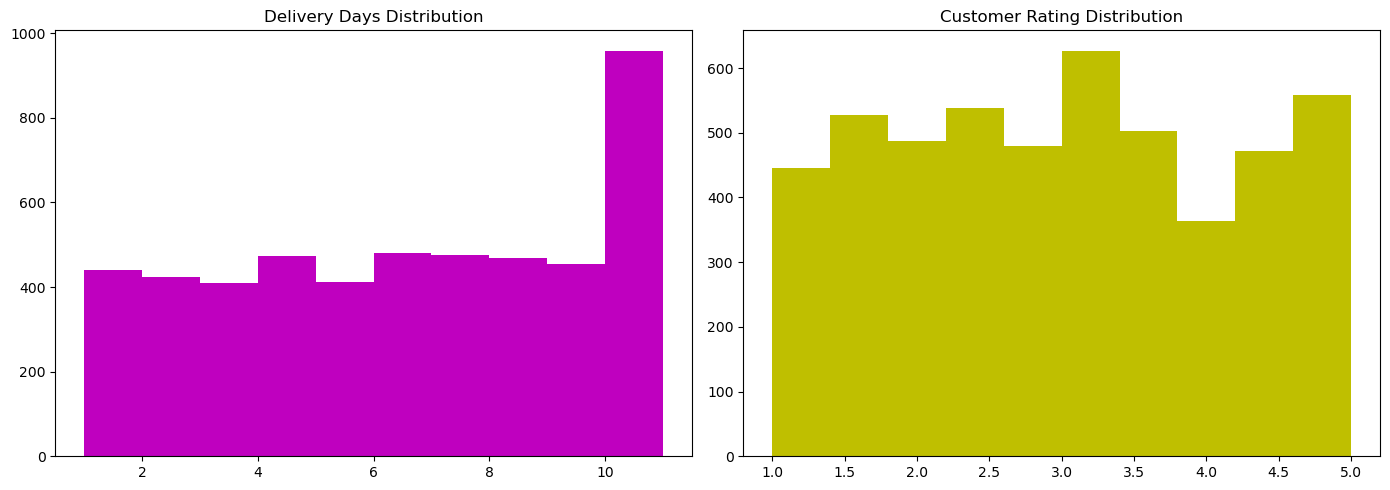

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Delivery Days Distribution
axes[0].hist(
    df["delivery_days"],
    bins=10,
    color="m"
)
axes[0].set_title(
    "Delivery Days Distribution"
)

# Customer Rating Distribution
axes[1].hist(
    df["customer_rating"],
    bins=10,
    color="y"
)
axes[1].set_title(
    "Customer Rating Distribution"
)

fig.savefig("Delivery Time & Customer Rating Analysis.png", dpi=100)
plt.tight_layout()
plt.show()

## 📊 Revenue Distribution Analysis (Histogram)

This section analyzes revenue distributions and the impact of discounts using multiple histogram visualizations.

The analysis includes:

1. `Revenue Frequency Distribution:`
   - Revenue spread and concentration
   - Shows how frequently revenue values occur across the dataset.
2. `Revenue Density Distribution:`
   - Distribution patterns
   - Displays normalized revenue distribution using probability density.
3. `Discounted Revenue Distribution:`
   - Effect of discounts on revenue
   - Visualizes revenue after applying discounts.
4. `Original vs Discounted Revenue Comparison:`
   - Comparison between original and discounted sales performance
   - Compares original and discounted revenue distributions in a combined histogram.
   - discounted_revenue = revenue × (1 - discount)

In [12]:
# Calculate Discounted Revenue
discounted_revenue = (df["revenue"] * (1 - df["discount"]))

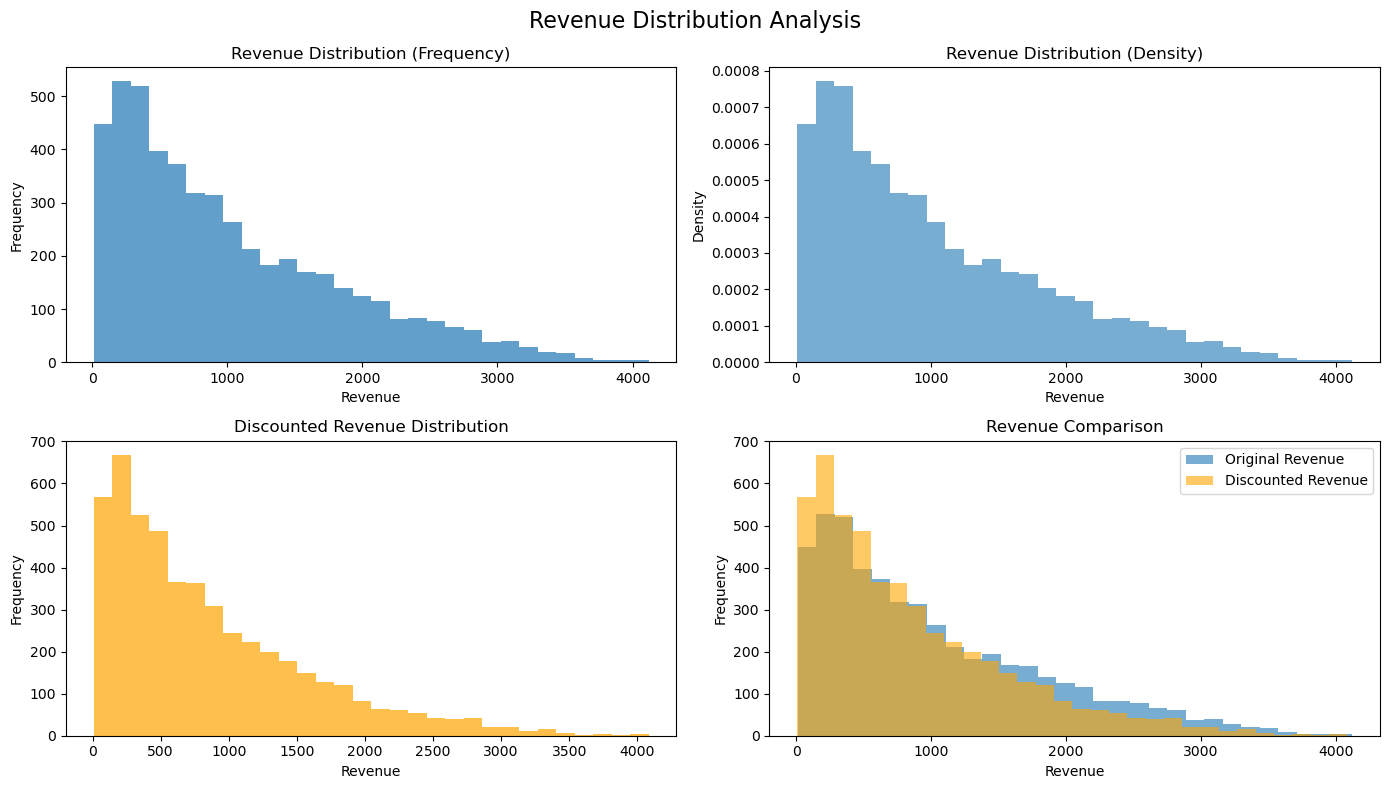

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

# Revenue Frequency
axes[0,0].hist(
    df["revenue"],
    bins=30,
    alpha=0.7
)
axes[0,0].set_title(
    "Revenue Distribution (Frequency)"
)
axes[0,0].set_xlabel("Revenue")
axes[0,0].set_ylabel("Frequency")

# Revenue Density
axes[0,1].hist(
    df["revenue"],
    bins=30,
    density=True,
    alpha=0.6
)
axes[0,1].set_title(
    "Revenue Distribution (Density)"
)
axes[0,1].set_xlabel("Revenue")
axes[0,1].set_ylabel("Density")

# Discounted Revenue
axes[1,0].hist(
    discounted_revenue,
    bins=30,
    color="orange",
    alpha=0.7
)
axes[1,0].set_title(
    "Discounted Revenue Distribution"
)
axes[1,0].set_xlabel("Revenue")
axes[1,0].set_ylabel("Frequency")

# Revenue Comparison
axes[1,1].hist(
    df["revenue"],
    bins=30,
    alpha=0.6,
    label="Original Revenue"
)
axes[1,1].hist(
    discounted_revenue,
    bins=30,
    alpha=0.6,
    color="orange",
    label="Discounted Revenue"
)
axes[1,1].set_title(
    "Revenue Comparison"
)
axes[1,1].set_xlabel("Revenue")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

# Main Title
fig.suptitle(
    "Revenue Distribution Analysis",
    fontsize=16
)
fig.savefig("Revenue Distribution Analysis.png", dpi=100)

plt.tight_layout()
plt.show()

## 📉 Monthly Revenue with Confidence Band

This section visualizes:

- Mean Monthly Revenue
- Standard Deviation Range

using a confidence band.

### Functions Used

- `fill_between()`: Fills area between upper and lower bounds.

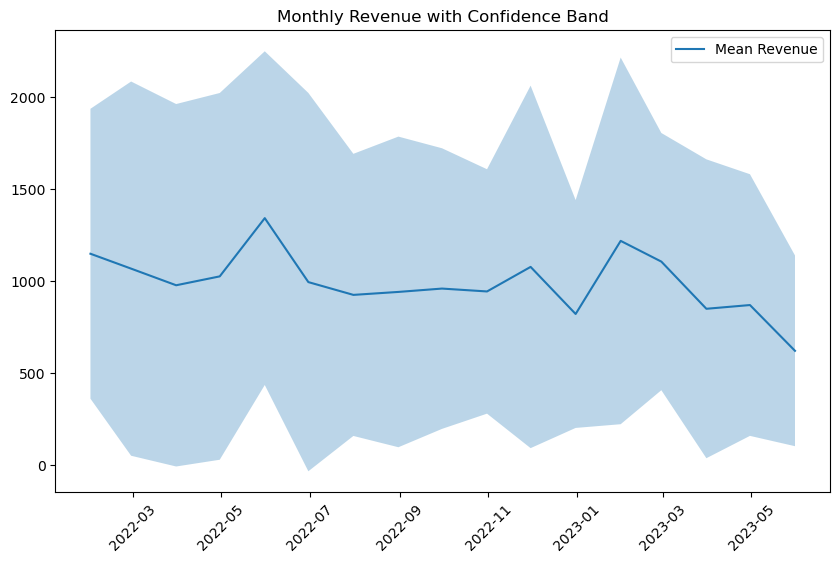

In [14]:
ds = df.head(500)
monthly = (
    ds.set_index("order_date")["revenue"]
    .resample("ME")
    .agg(["mean", "std"])
)
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(
    monthly.index,
    monthly["mean"],
    label="Mean Revenue"
)
ax.fill_between(
    monthly.index,
    monthly["mean"] - monthly["std"],
    monthly["mean"] + monthly["std"],
    alpha=0.3
)
ax.tick_params(
    axis="x",
    rotation=45
)
ax.set_title(
    "Monthly Revenue with Confidence Band"
)
ax.legend()
fig.savefig("Monthly Revenue with Confidence Band.png", dpi=100)
plt.show()